In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [23]:
import re
import pandas as pd
from pathlib import Path

log_dir = Path("../slurm_outs")

records = []

for f in log_dir.glob("*.out"):

    txt = open(f).read()

    # correlation
    corr_match = re.search(r"Final correlation:\s*([0-9.]+)", txt)
    if not corr_match:
        continue

    corr = float(corr_match.group(1))

    # seed
    seed_match = re.search(r"Running seed\s*(\d+)", txt)
    seed = int(seed_match.group(1)) if seed_match else None

    # parse slurm job id
    m = re.search(r"slurm-(\d+)_?(\d+)?", f.name)
    job = int(m.group(1))
    idx = int(m.group(2)) if m.group(2) else 0

    depth = None
    width = None
    frac = None

    # ---- decode experiment type ----

    if job == 16527818:   # depth ablation
        depth = idx // 7

    elif job == 16528003: # width ablation
        widths = [512,1024,2048,4096]
        width = widths[idx // 7]

    elif job == 16528091: # fraction ablation
        fracs = [0.1,0.25,0.5,0.75,1.0]
        frac = fracs[idx // 7]

    records.append({
        "file": f.name,
        "seed": seed,
        "depth": depth,
        "width": width,
        "frac": frac,
        "corr": corr
    })

df = pd.DataFrame(records)

print("Runs parsed:", len(df))
df.head()

Runs parsed: 132


,file,seed,depth,width,frac,corr
0,slurm-16527488.out,NaN,NaN,NaN,NaN,0.2627
1,slurm-16527700_0.out,0.0,NaN,NaN,NaN,0.2627
2,slurm-16527700_1.out,1.0,NaN,NaN,NaN,0.2758
3,slurm-16527700_2.out,2.0,NaN,NaN,NaN,0.2761
4,slurm-16527700_3.out,3.0,NaN,NaN,NaN,0.2586


In [ ]:
depth_summary = (
    df[df.depth.notna()]
    .groupby("depth")
    .agg(mean_corr=("corr","mean"),
         std_corr=("corr","std"),
         n=("corr","count"))
    .reset_index()
)

depth_summary.head()


width_summary = (
    df[df.width.notna()]
    .groupby("width")
    .agg(mean_corr=("corr","mean"),
         std_corr=("corr","std"),
         n=("corr","count"))
    .reset_index()
)

width_summary.head()


frac_summary = (
    df[df.frac.notna()]
    .groupby("frac")
    .agg(mean_corr=("corr","mean"),
         std_corr=("corr","std"),
         n=("corr","count"))
    .reset_index()
)

frac_summary.head()

,depth,mean_corr,std_corr,n
0,0.0,0.287129,0.001754,7
1,1.0,0.282143,0.006619,7
2,2.0,0.269329,0.007755,7
3,3.0,0.273300,0.007345,7
4,4.0,0.273386,0.005000,7
5,5.0,0.273071,0.005936,7
6,6.0,0.268486,0.008514,7


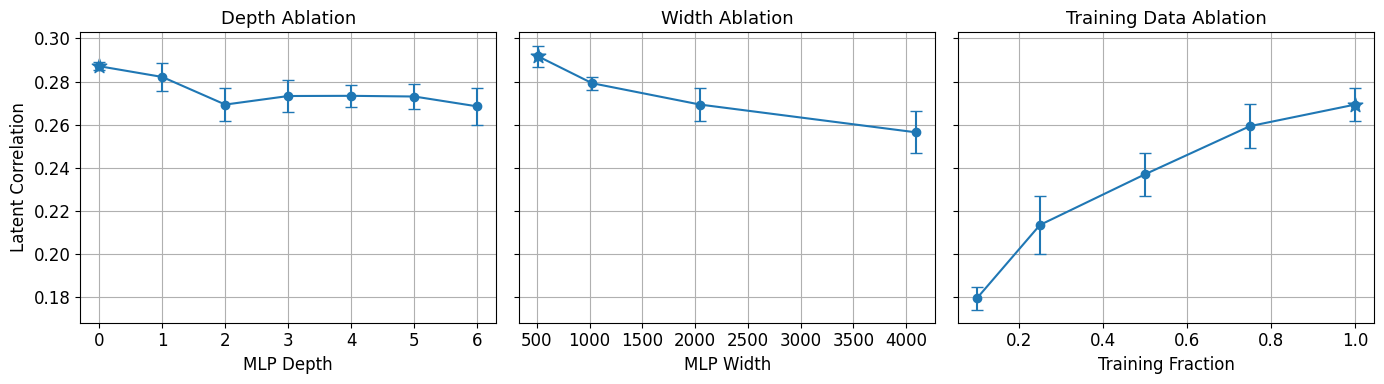

In [28]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12
})

fig, axes = plt.subplots(1,3,figsize=(14,4),sharey=True)

# Depth
axes[0].errorbar(
    depth_summary.depth,
    depth_summary.mean_corr,
    yerr=depth_summary.std_corr,
    marker="o",
    markersize=6,
    capsize=4
)
axes[0].scatter(
    depth_summary.loc[depth_summary.mean_corr.idxmax(),"depth"],
    depth_summary.mean_corr.max(),
    s=120,
    marker="*"
)
axes[0].set_title("Depth Ablation")
axes[0].set_xlabel("MLP Depth")
axes[0].set_ylabel("Latent Correlation")
axes[0].grid(True)

# Width
axes[1].errorbar(
    width_summary.width,
    width_summary.mean_corr,
    yerr=width_summary.std_corr,
    marker="o",
    markersize=6,
    capsize=4
)
axes[1].scatter(
    width_summary.loc[width_summary.mean_corr.idxmax(),"width"],
    width_summary.mean_corr.max(),
    s=120,
    marker="*"
)
axes[1].set_title("Width Ablation")
axes[1].set_xlabel("MLP Width")
axes[1].grid(True)

# Fraction
axes[2].errorbar(
    frac_summary.frac,
    frac_summary.mean_corr,
    yerr=frac_summary.std_corr,
    marker="o",
    markersize=6,
    capsize=4
)
axes[2].scatter(
    frac_summary.loc[frac_summary.mean_corr.idxmax(),"frac"],
    frac_summary.mean_corr.max(),
    s=120,
    marker="*"
)
axes[2].set_title("Training Data Ablation")
axes[2].set_xlabel("Training Fraction")
axes[2].grid(True)

plt.tight_layout()
plt.savefig("mlp_ablation_cvpr.png",dpi=300,bbox_inches="tight")
plt.show()


Looking in: /home/ec2-user/Brain2VLM/decoded/image-mlp_seed0_d2_w2048_frac1.0-early/subj01/samples
  exists: True
  first files: ['00000_000.png', '00000_001.png', '00000_002.png', '00000_003.png', '00000_004.png', '00000_org.png']

Looking in: /home/ec2-user/Brain2VLM/decoded/image-mlp_seed0_d2_w2048_frac1.0-lateral/subj01/samples
  exists: True
  first files: ['00000_000.png', '00000_001.png', '00000_002.png', '00000_003.png', '00000_004.png', '00000_org.png']

Looking in: /home/ec2-user/Brain2VLM/decoded/image-mlp_seed0_d2_w2048_frac1.0-ventral/subj01/samples
  exists: True
  first files: ['00000_000.png', '00000_001.png', '00000_002.png', '00000_003.png', '00000_004.png', '00000_org.png']

image-mlp_seed0_d2_w2048_frac1.0-early: 5 stimuli → ['00000', '00095', '00240', '00480'] ...

image-mlp_seed0_d2_w2048_frac1.0-lateral: 5 stimuli → ['00000', '00095', '00240', '00480'] ...

image-mlp_seed0_d2_w2048_frac1.0-ventral: 5 stimuli → ['00000', '00095', '00240', '00480'] ...

Stimuli in

✓  Saved → cvpr_mosaic_all_rois.pdf


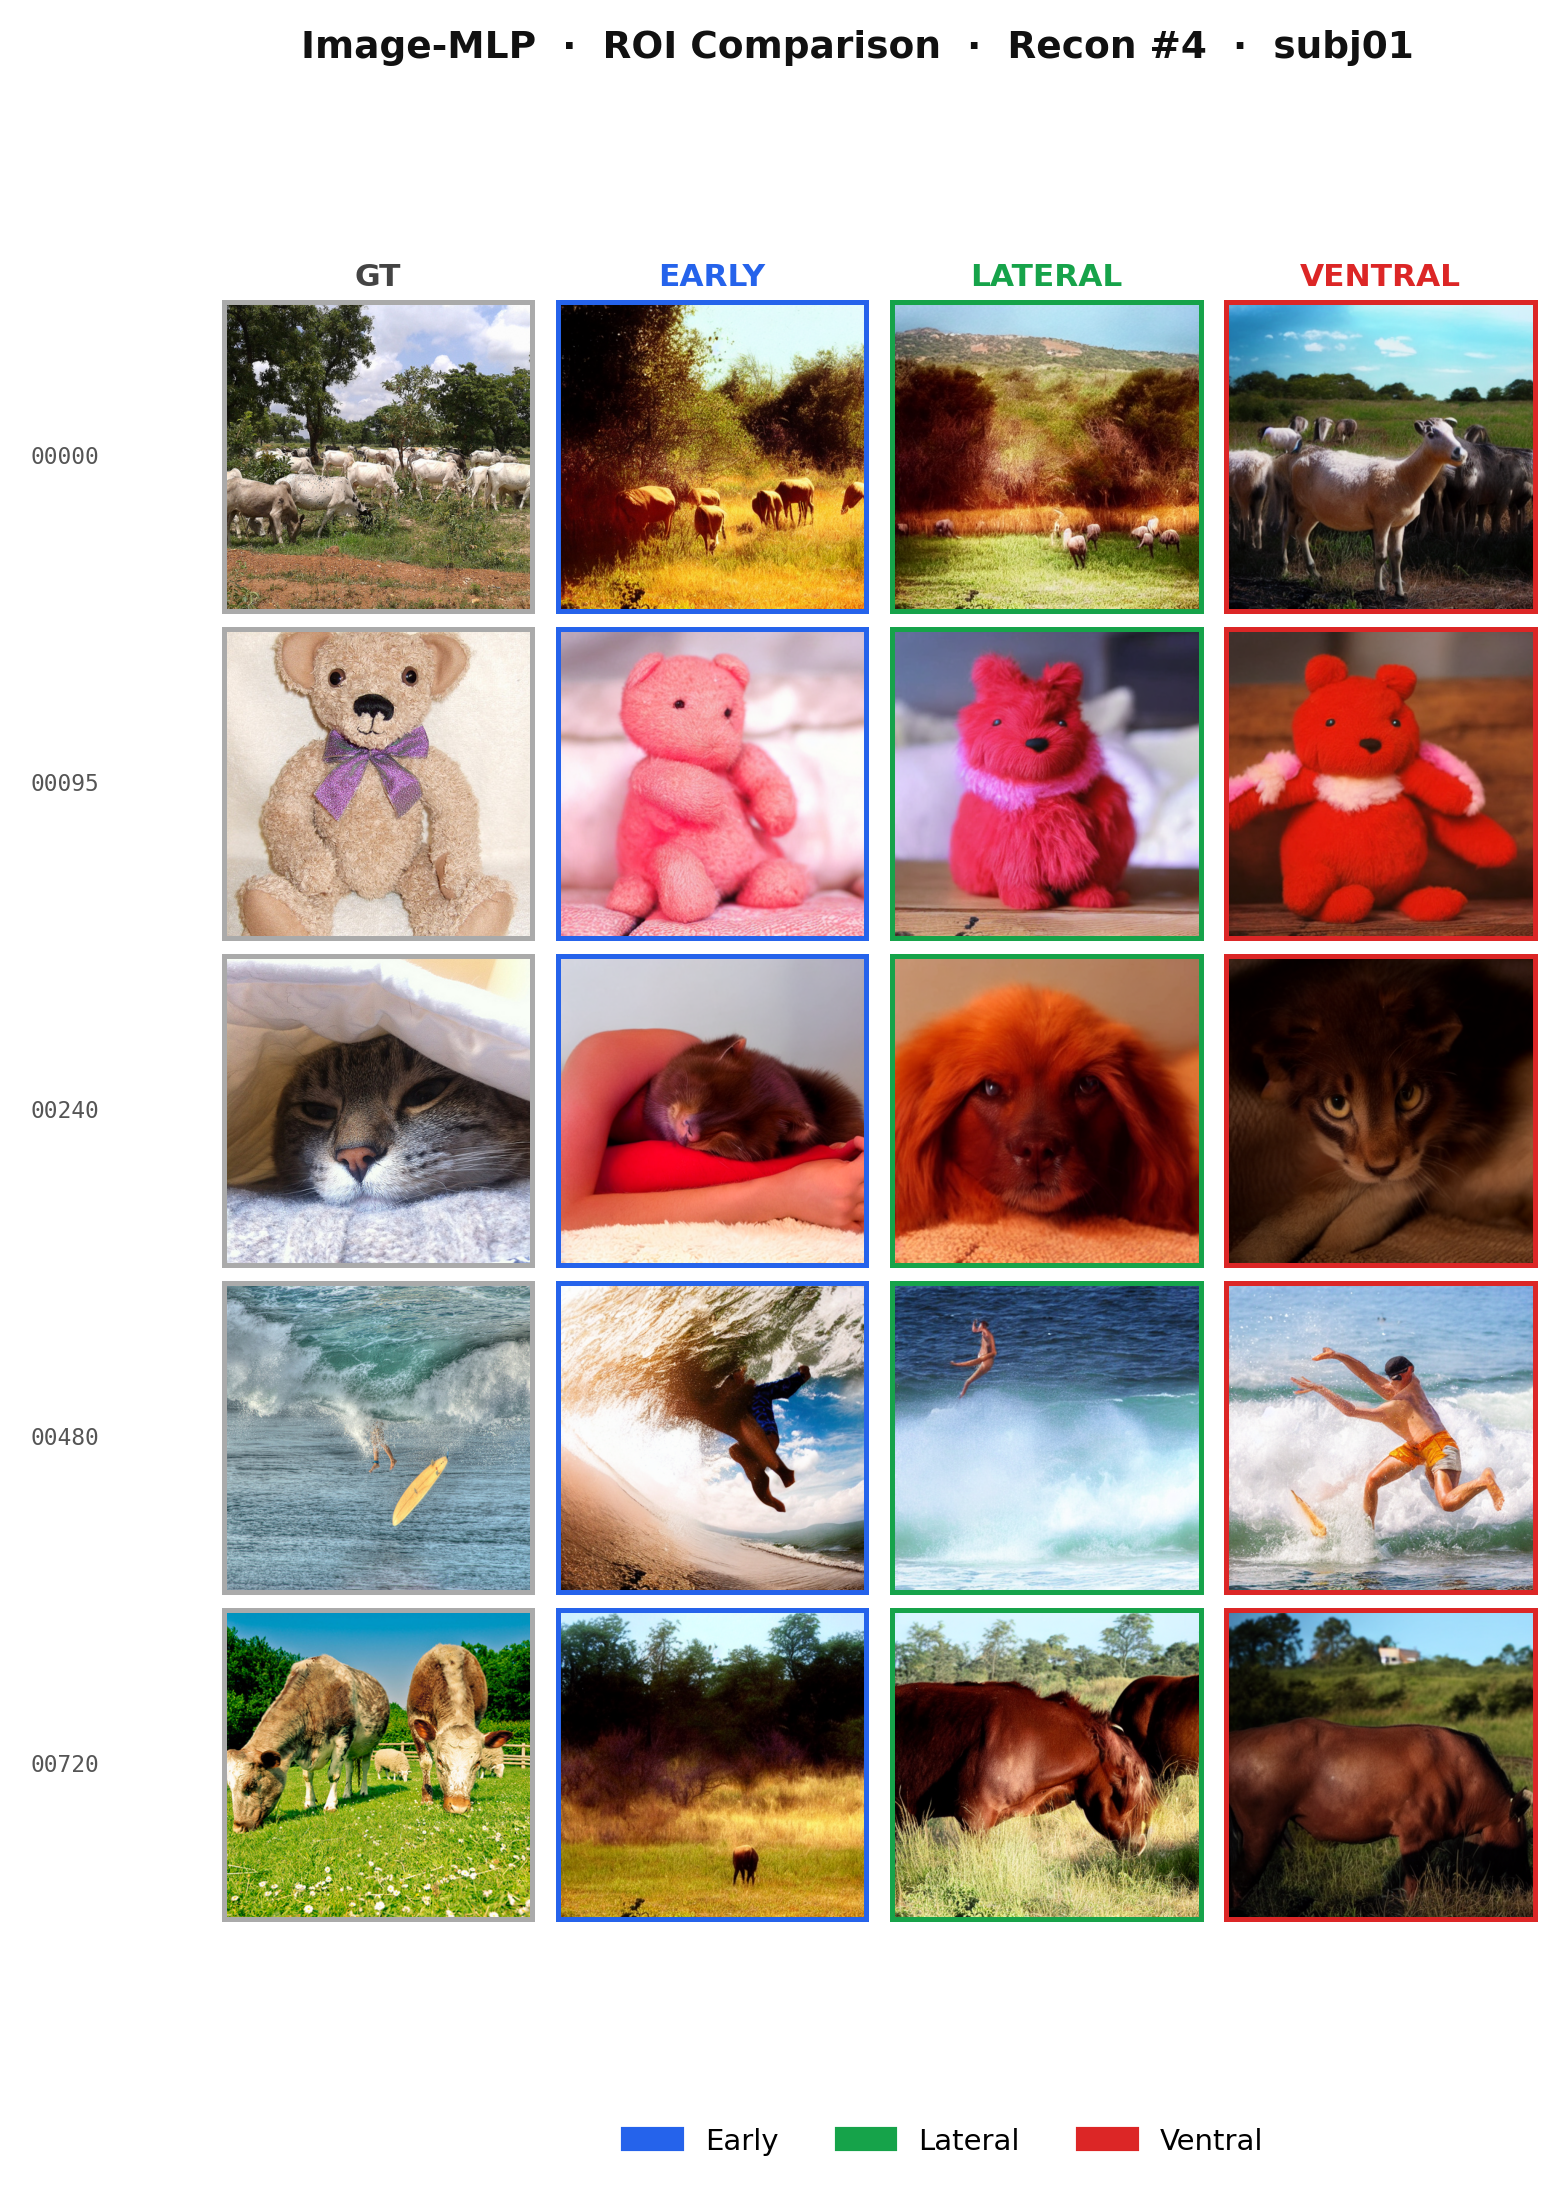

In [12]:
"""
CVPR Mosaic — All ROIs × All Stimuli
=====================================
Grid layout:
  rows    = stimuli  (00000, 00240, 00480, 00720, ...)
  columns = [GT | early | lateral | ventral]

Each cell shows the 4th reconstruction (_003) for that ROI,
and the first column is always the original (_org).
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from PIL import Image

# ── CONFIG ───────────────────────────────────────────────────────────────────
BASE    = Path("/home/ec2-user/Brain2VLM/decoded")
SUBJECT = "subj01"

ROIS = [
    ("early",   "image-mlp_seed0_d2_w2048_frac1.0-early"),
    ("lateral", "image-mlp_seed0_d2_w2048_frac1.0-lateral"),
    ("ventral", "image-mlp_seed0_d2_w2048_frac1.0-ventral"),
]

RECON_IDX = 3        # 0-indexed → 4th reconstruction (_003)
DPI       = 300
OUT_PATH  = "cvpr_mosaic_all_rois.pdf"

ROI_COLORS = {
    "early":   "#2563EB",   # blue
    "lateral": "#16A34A",   # green
    "ventral": "#DC2626",   # red
}

# ── HELPERS ──────────────────────────────────────────────────────────────────
def samples_dir(roi_folder):
    return BASE / roi_folder / SUBJECT / "samples"

def load(path):
    return np.array(Image.open(path).convert("RGB"))

# ── DEBUG: print actual paths so you can verify ──────────────────────────────
for _, folder in ROIS:
    d = samples_dir(folder)
    print(f"\nLooking in: {d}")
    print(f"  exists: {d.exists()}")
    if d.exists():
        files = sorted(d.iterdir())[:6]
        print(f"  first files: {[f.name for f in files]}")

# ── DISCOVER STIMULI (union across all ROIs, warn on missing) ─────────────────
id_sets = {}
for _, folder in ROIS:
    d = samples_dir(folder)
    # Try both *_org.png and any png to understand naming
    org_files = sorted(d.glob("*_org.png"))
    ids = [p.stem.replace("_org", "") for p in org_files]
    id_sets[folder] = set(ids)
    print(f"\n{folder}: {len(ids)} stimuli → {ids[:4]} ...")

# Intersection: only stimuli present in every ROI
all_ids = sorted(set.intersection(*id_sets.values())) if id_sets else []
print(f"\nStimuli in ALL ROIs: {len(all_ids)}")
print(all_ids)

assert len(all_ids) > 0, (
    "No stimuli found! Check BASE path and that *_org.png files exist. "
    f"BASE={BASE}, SUBJECT={SUBJECT}"
)

# ── LOAD IMAGES ───────────────────────────────────────────────────────────────
data = {}
for sid in all_ids:
    entry = {}
    org_path = samples_dir(ROIS[0][1]) / f"{sid}_org.png"
    entry["org"] = load(org_path)

    for roi_name, folder in ROIS:
        rpath = samples_dir(folder) / f"{sid}_{RECON_IDX:03d}.png"
        if rpath.exists():
            entry[roi_name] = load(rpath)
        else:
            print(f"  [warn] missing {rpath}")
            h, w = entry["org"].shape[:2]
            entry[roi_name] = np.full((h, w, 3), 200, dtype=np.uint8)  # grey placeholder

    data[sid] = entry

# ── FIGURE LAYOUT ─────────────────────────────────────────────────────────────
N_STIM = len(all_ids)
N_COLS = 1 + len(ROIS)   # GT + one per ROI

COL_W    = 1.3
ROW_H    = 1.3

fig_w = N_COLS * COL_W + 0.5
fig_h = N_STIM * ROW_H + 0.5

fig, axes = plt.subplots(
    N_STIM, N_COLS,
    figsize=(fig_w, fig_h),
    dpi=DPI,
    gridspec_kw=dict(hspace=0.06, wspace=0.035),
)
fig.patch.set_facecolor("white")

if N_STIM == 1:
    axes = axes[np.newaxis, :]

col_labels = ["GT"] + [r[0] for r in ROIS]

for row_i, sid in enumerate(all_ids):
    imgs = [data[sid]["org"]] + [data[sid][r[0]] for r in ROIS]

    for col_i, img in enumerate(imgs):
        ax = axes[row_i, col_i]
        ax.imshow(img)
        ax.set_xticks([])
        ax.set_yticks([])

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.2)

        if col_i == 0:
            for spine in ax.spines.values():
                spine.set_edgecolor("#AAAAAA")
            ax.set_ylabel(sid, fontsize=5.5, color="#555",
                          rotation=0, labelpad=30,
                          va="center", ha="right",
                          fontfamily="monospace")
        else:
            roi_name = col_labels[col_i]
            for spine in ax.spines.values():
                spine.set_edgecolor(ROI_COLORS[roi_name])

        # Column headers on first row only
        if row_i == 0:
            color = "#444" if col_i == 0 else ROI_COLORS[col_labels[col_i]]
            ax.set_title(col_labels[col_i].upper(), fontsize=7.5,
                         color=color, fontweight="bold", pad=4)

# ── LEGEND ────────────────────────────────────────────────────────────────────
patches = [mpatches.Patch(color=ROI_COLORS[r[0]], label=r[0].capitalize()) for r in ROIS]
fig.legend(
    handles=patches, loc="lower center",
    ncol=len(ROIS), fontsize=7,
    frameon=False,
    bbox_to_anchor=(0.55, -0.015),
)

fig.suptitle(
    f"Image-MLP  ·  ROI Comparison  ·  Recon #{RECON_IDX + 1}  ·  {SUBJECT}",
    fontsize=9, fontweight="bold", color="#111", y=1.01,
)

# ── SAVE ─────────────────────────────────────────────────────────────────────
plt.savefig(OUT_PATH, dpi=DPI, bbox_inches="tight",
            facecolor="white", format=OUT_PATH.split(".")[-1])
print(f"✓  Saved → {OUT_PATH}")
plt.show()